<a href="https://colab.research.google.com/github/mamontoff2018-lgtm/google-colab/blob/main/MO7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
dataset = pd.read_csv('data.csv')
dataset.head()

,Country,Age,Salary,Purchased
0,France,44.0,72000.0,No
1,Spain,27.0,48000.0,Yes
2,Germany,30.0,54000.0,No
3,Spain,38.0,61000.0,No
4,Germany,40.0,NaN,Yes


In [5]:
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, 3].values

print("Матрица признаков"); print(X)
print("Зависимая переменная"); print(y)

Матрица признаков
[['France' 44.0 72000.0]
 ['Spain' 27.0 48000.0]
 ['Germany' 30.0 54000.0]
 ['Spain' 38.0 61000.0]
 ['Germany' 40.0 nan]
 ['France' 35.0 58000.0]
 ['Spain' nan 52000.0]
 ['France' 48.0 79000.0]
 ['Germany' 50.0 83000.0]
 ['France' 37.0 67000.0]]
Зависимая переменная
['No' 'Yes' 'No' 'No' 'Yes' 'Yes' 'No' 'Yes' 'No' 'Yes']


In [10]:
from sklearn.impute import SimpleImputer

dataset = pd.read_csv('data.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, 3].values

# Обработка пропущенных значений
imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
imputer = imputer.fit(X[:, 1:3])
X[:, 1:3] = imputer.transform(X[:, 1:3])

print(X)

[['France' 44.0 72000.0]
 ['Spain' 27.0 48000.0]
 ['Germany' 30.0 54000.0]
 ['Spain' 38.0 61000.0]
 ['Germany' 40.0 63777.77777777778]
 ['France' 35.0 58000.0]
 ['Spain' 38.77777777777778 52000.0]
 ['France' 48.0 79000.0]
 ['Germany' 50.0 83000.0]
 ['France' 37.0 67000.0]]


In [7]:
from sklearn.preprocessing import LabelEncoder

labelencoder_y = LabelEncoder()
print("Зависимая переменная до обработки")
print(y)
y = labelencoder_y.fit_transform(y)
print("Зависимая переменная после обработки")
print(y)

Зависимая переменная до обработки
['No' 'Yes' 'No' 'No' 'Yes' 'Yes' 'No' 'Yes' 'No' 'Yes']
Зависимая переменная после обработки
[0 1 0 0 1 1 0 1 0 1]


In [12]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Сначала кодируем категориальный признак
labelencoder_X = LabelEncoder()
X[:, 0] = labelencoder_X.fit_transform(X[:, 0])

onehotencoder = OneHotEncoder(drop='first', sparse_output=False)
X_encoded = onehotencoder.fit_transform(X[:, [0]])
X = np.hstack((X_encoded, X[:, 1:3]))

print("Перекодировка категориального признака")
print(X)

Перекодировка категориального признака
[[0.0 0.0 44.0 72000.0]
 [0.0 1.0 27.0 48000.0]
 [1.0 0.0 30.0 54000.0]
 [0.0 1.0 38.0 61000.0]
 [1.0 0.0 40.0 63777.77777777778]
 [0.0 0.0 35.0 58000.0]
 [0.0 1.0 38.77777777777778 52000.0]
 [0.0 0.0 48.0 79000.0]
 [1.0 0.0 50.0 83000.0]
 [0.0 0.0 37.0 67000.0]]


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print('Размер обучающей выборки:', train_df.shape)
print('Размер тестовой выборки:', test_df.shape)
print('\nПервые 5 строк train:')
display(train_df.head())

Размер обучающей выборки: (891, 12)
Размер тестовой выборки: (418, 11)

Первые 5 строк train:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [18]:
print('Информация о данных (train)')
train_df.info()
print('\nСтатистическое описание')
display(train_df.describe())
print('\nПропущенные значения (train)')
print(train_df.isnull().sum())

Информация о данных (train)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Статистическое описание


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Пропущенные значения (train)
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


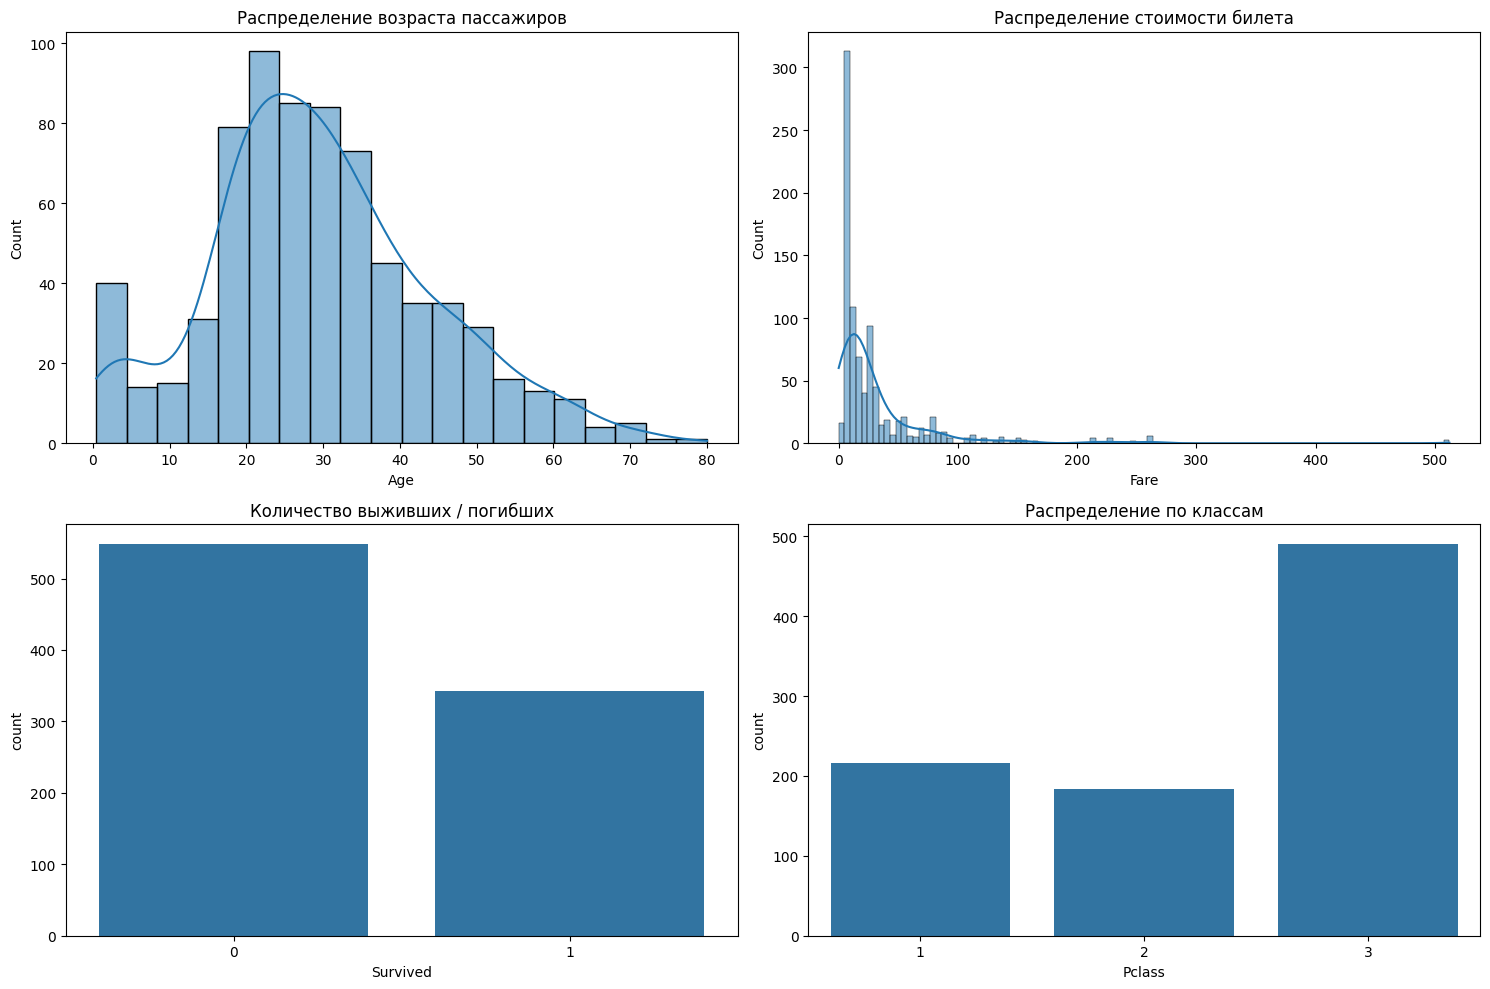

In [21]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.histplot(train_df['Age'].dropna(), kde=True)
plt.title('Распределение возраста пассажиров')

plt.subplot(2, 2, 2)
sns.histplot(train_df['Fare'], kde=True)
plt.title('Распределение стоимости билета')

plt.subplot(2, 2, 3)
sns.countplot(x='Survived', data=train_df)
plt.title('Количество выживших / погибших')

plt.subplot(2, 2, 4)
sns.countplot(x='Pclass', data=train_df)
plt.title('Распределение по классам')

plt.tight_layout()
plt.show()

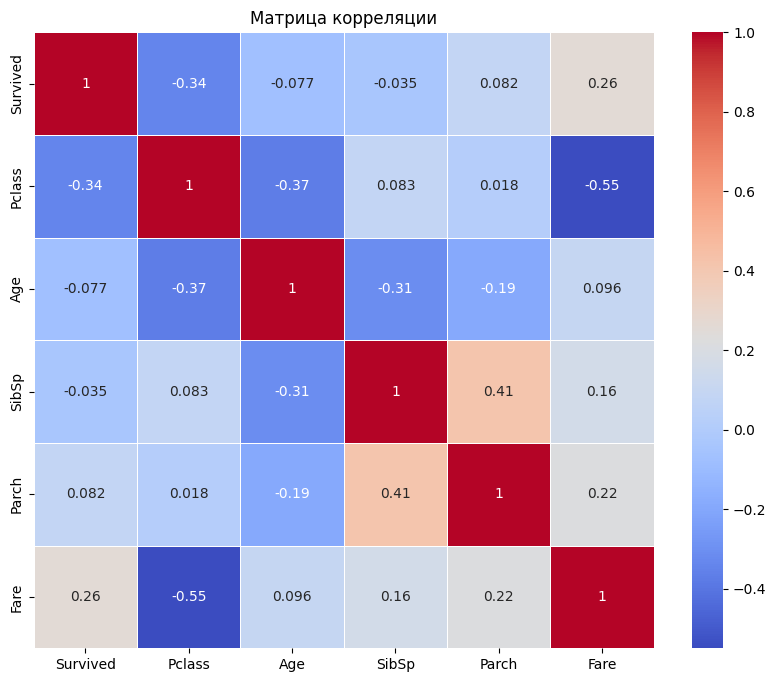

In [22]:
plt.figure(figsize=(10, 8))
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr_matrix = train_df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Матрица корреляции')
plt.show()

In [23]:
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())
test_df['Age'] = test_df['Age'].fillna(test_df['Age'].median())

train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])
test_df['Embarked'] = test_df['Embarked'].fillna(test_df['Embarked'].mode()[0])

# Cabin — слишком много пропусков, создаём бинарный признак "Есть каюта"
train_df['Has_Cabin'] = train_df['Cabin'].notnull().astype(int)
test_df['Has_Cabin'] = test_df['Cabin'].notnull().astype(int)

# Удаляем столбец Cabin
train_df = train_df.drop(['Cabin'], axis=1)
test_df = test_df.drop(['Cabin'], axis=1)

print('Пропущенные значения после обработки (train):')
print(train_df.isnull().sum())

Пропущенные значения после обработки (train):
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Has_Cabin      0
dtype: int64


In [63]:
# Разделяем на train и test
train_df, test_df = train_test_split(titanic, test_size=0.3, random_state=42)

categorical_features = ['sex', 'embarked', 'pclass']

train_df = pd.get_dummies(train_df, columns=categorical_features, drop_first=True)
test_df = pd.get_dummies(test_df, columns=categorical_features, drop_first=True)

# Приводим test к тем же столбцам, что и train
test_df = test_df.reindex(columns=train_df.columns.drop('survived'), fill_value=0)

print("\nПосле обработки")
print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)
print(train_df.head())


После обработки
Train shape: (623, 17)
Test shape: (268, 16)
     survived   age  sibsp  parch     fare   class    who  adult_male deck  \
445         1   4.0      0      2  81.8583   First  child       False    A   
650         0   NaN      0      0   7.8958   Third    man        True  NaN   
172         1   1.0      1      1  11.1333   Third  child       False  NaN   
450         0  36.0      1      2  27.7500  Second    man        True  NaN   
314         0  43.0      1      1  26.2500  Second    man        True  NaN   

     embark_town alive  alone  sex_male  embarked_Q  embarked_S  pclass_2  \
445  Southampton   yes  False      True       False        True     False   
650  Southampton    no   True      True       False        True     False   
172  Southampton   yes  False     False       False        True     False   
450  Southampton    no  False      True       False        True      True   
314  Southampton    no  False      True       False        True      True   

     p

In [32]:
from sklearn.model_selection import train_test_split

y = train_df['Survived']
X = train_df.drop(['Survived', 'PassengerId', 'Name', 'Ticket'], axis=1)

# Разделение train на train и validation (80/20)
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Финальная тестовая выборка (test.csv)
X_test = test_df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, errors='ignore')

print('Размеры после разделения:')
print('X_train:', X_train.shape)
print('X_valid:', X_valid.shape)
print('X_test:', X_test.shape)

Размеры после разделения:
X_train: (712, 10)
X_valid: (179, 10)
X_test: (418, 10)
